In [22]:
import pandas as pd
import thebeat
import matplotlib.pyplot as plt
import os

In [23]:
# Load ITIs df
df = pd.read_csv(os.path.join('data', 'experiment', 'processed', 'ITIs.csv'))
df_bytrial = pd.read_csv(os.path.join('data', 'experiment', 'processed', 'ITIs_bytrial.csv'))
quantized_df = pd.read_csv(os.path.join('data', 'experiment', 'processed', 'ITIs_quantized.csv'))

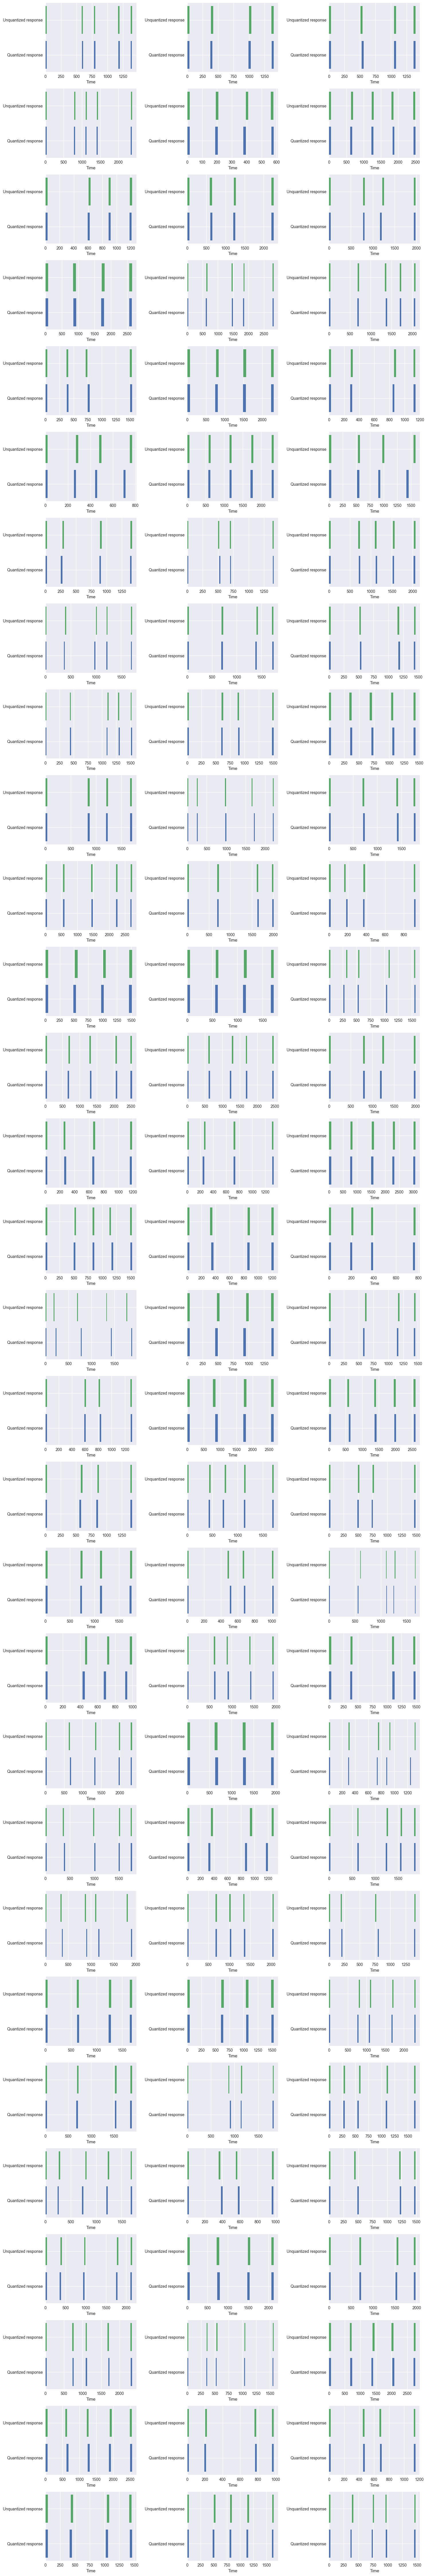

In [24]:
plt.style.use('seaborn-v0_8')

fig, axs = plt.subplots(30, 3, figsize=(15, 90), tight_layout=True)

sequence_ids = df_bytrial.sample(90).sequence_id.values
quantized_df_short = quantized_df[quantized_df.sequence_id.isin(sequence_ids)]

count = 0

for seq_id, seq_df in quantized_df_short.groupby('sequence_id'):
    unquantized_resp = thebeat.Sequence(seq_df['resp_iti'].values)
    quantized_resp = thebeat.Sequence(seq_df['resp_iti_q'].values)

    thebeat.visualization.plot_multiple_sequences([unquantized_resp, quantized_resp], y_axis_labels=['Unquantized response', 'Quantized response'],
                                                   ax=axs[count // 3, count % 3])
    count += 1